# LDA Model
## Marissa Burton

### Import packages

In [72]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA, LatentDirichletAllocation as LDA, NMF

### Set OHCO

In [73]:
model_type = 'lda'
OHCO = ['era','book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
PARA = OHCO[:4]
CHAP = OHCO[:3]
BOOK = OHCO[:2]
ERA = OHCO[:1]
BAG = CHAP

### Load in CORPUS

In [74]:
CORPUS = pd.read_csv('data/CORPUS.csv')

/var/folders/k2/xkhh4x_x2999dprlhrz1h_r00000gn/T/ipykernel_29069/1873822874.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  CORPUS = pd.read_csv('data/CORPUS.csv')


### Create DOCS table and filter for nouns

In [75]:
DOCS = CORPUS.groupby(BAG).term_str\
    .apply(lambda x: ' '.join(map(str,x)))\
    .to_frame()\
    .rename(columns={'term_str':'doc_str'})

### Set stop words

In [76]:
from sklearn.feature_extraction import text

my_stop_words = list(text.ENGLISH_STOP_WORDS.union(['yes']))

### Create Vector Space

In [77]:
count_engine = CountVectorizer(max_df=.9, min_df=10, stop_words=my_stop_words)
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
VOCAB = pd.DataFrame(index=TERMS)
VOCAB.index.name = 'term_str'
DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
DTM

17  abandoned  able  abroad  \
era                       book_id chap_num                                
classical/romantic gothic 6087    1          0          0     0       0   
                                  2          0          0     0       0   
                                  3          0          0     0       0   
                                  4          0          0     0       0   
                          41445   1          0          0     0       0   
...                                         ..        ...   ...     ...   
victorian gothic          345     24         0          0     4       0   
                                  25         1          0     0       0   
                                  26         0          0     2       0   
                                  27         0          0     1       0   
                          1952    0          0          0     4       0   

                                            abruptly  absence  absent  \
era                       book_id chap_num                              
classical/romantic gothic 6087    1                0        0       0   
                                  2                0        0       0   
                                  3                0        0       0   
                                  4                1        1       0   
                          41445   1                0        0       1   
...                                              ...      ...     ...   
victorian gothic          345     24               0        0       0   
                                  25               0        0       0   
                                  26               0        0       0   
                                  27               0        0       0   
                          1952    0                0        0       0   

                                            absolute  absolutely  absorbed  \
era                       book_id chap_num                                   
classical/romantic gothic 6087    1                0           0         0   
                                  2                0           0         0   
                                  3                0           0         0   
                                  4                0           0         3   
                          41445   1                0           0         0   
...                                              ...         ...       ...   
victorian gothic          345     24               0           0         0   
                                  25               1           0         0   
                                  26               0           0         0   
                                  27               0           0         0   
                          1952    0                0           1         0   

                                            ...  years  yellow  yesterday  \
era                       book_id chap_num  ...                             
classical/romantic gothic 6087    1         ...      1       0          0   
                                  2         ...      0       0          0   
                                  3         ...      1       1          0   
                                  4         ...      1       0          0   
                          41445   1         ...      9       0          0   
...                                         ...    ...     ...        ...   
victorian gothic          345     24        ...      1       0          2   
                                  25        ...      0       0          1   
                                  26        ...      1       0          0   
                                  27        ...      2       1          2   
                          1952    0         ...      1       8          0   

                                            yield  yielded  young  younger  \
era                    

### Generate Model

In [78]:
n_topics = 20
max_iter = 100
n_top_terms = 5
TNAMES = [f"T{str(x).zfill(len(str(n_topics)))}" for x in range(n_topics)]

In [79]:
topic_engine = LDA(n_components=n_topics, max_iter=max_iter)
topic_model = topic_engine.fit_transform(count_model)

### THETA

In [80]:
THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'
THETA.sample(10).T.style.background_gradient(cmap='Blues')

### PHI

In [81]:
PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'
PHI.T.sample(10).T.style.background_gradient(cmap='Blues')

term_str,incoherent,certainty,took,accept,stairs,variety,created,existed,preceding,thunder
topic_id,,,,,,,,,,
T00,2.005177,4.045238,87.566020,18.432375,15.699487,1.109389,0.050000,0.050000,2.443735,0.050000
T01,0.050000,0.050000,1.746381,0.050000,2.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T02,0.050000,0.050000,15.323886,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T03,0.050000,0.050000,17.801111,0.050000,0.050000,0.050000,6.287724,0.050000,0.050000,1.050000
T04,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T05,3.854412,0.050000,43.300609,3.777826,6.904774,0.050000,0.050000,3.459509,0.050000,0.050000
T06,2.008341,1.247347,46.687597,5.793915,38.151693,0.050000,2.262506,2.431865,0.050000,0.050000
T07,0.050000,0.050000,52.942789,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,7.090763
T08,0.050000,2.050000,132.153566,14.841441,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000


### TOPICS

In [82]:
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')
TOPICS

,top_terms
topic_id,
T00,nan sir lord shall father
T01,old white wish son wife
T02,old cottage night wood young
T03,richard moncharmin ghost giry box
T04,rare harmless topic contrived exertion
T05,christine raoul erik voice nt
T06,house doctor door mrs room
T07,nan night came sleep saw
T08,nan shall come mina helsing


#### TOPICS sorted by document weights

In [83]:
TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS.sort_values('doc_weight_sum', ascending=False).style.background_gradient(cmap='YlGnBu', axis=0)

,top_terms,doc_weight_sum,term_freq
topic_id,,,
T11,father shall elizabeth mind life,17.970853,0.089044
T06,house doctor door mrs room,16.632289,0.141644
T05,christine raoul erik voice nt,14.851126,0.072747
T08,nan shall come mina helsing,14.301119,0.126501
T19,emily st aubert nan valancourt,10.584997,0.093251
T14,life moment god felt day,8.309165,0.078744
T07,nan night came sleep saw,8.273738,0.071147
T09,nan father thou thy lord,7.261162,0.082163
T17,nan mr hyde door lawyer,5.066857,0.027277


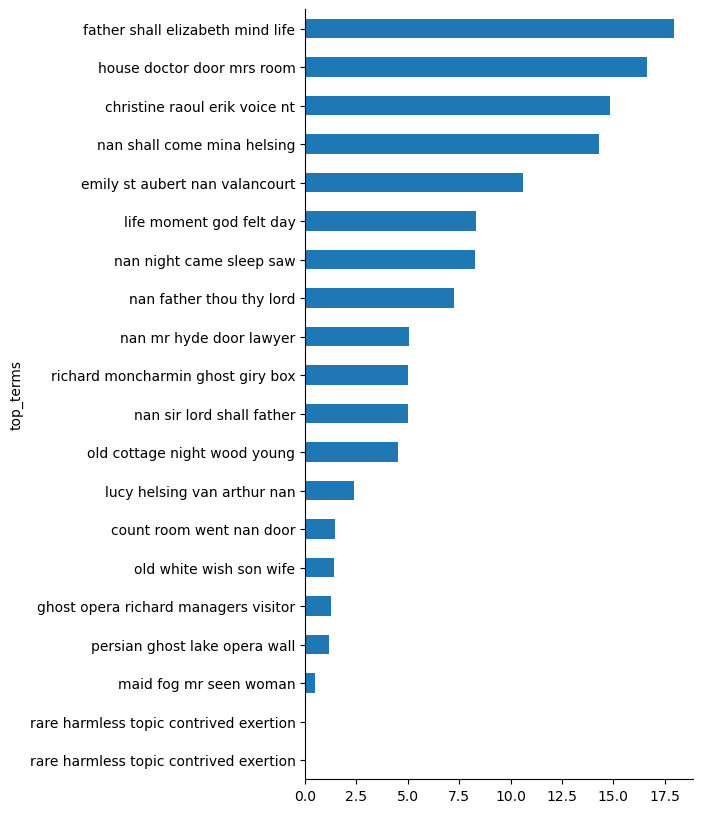

In [84]:
TOPICS.sort_values('doc_weight_sum', ascending=True).plot.barh(y='doc_weight_sum', x='top_terms', figsize=(5, n_topics/2), legend=False)
sns.despine()
plt.show()

### PCA on LDA

In [93]:
THETAX = THETA.T

In [94]:
pca_engine = PCA(n_components=5)
DCM = pd.DataFrame(pca_engine.fit_transform(THETAX), index=THETAX.index)
DCM.columns = ['PC{}'.format(i) for i in DCM.columns]
DCM['mean_weight'] = THETA.mean(axis=0)
DCM

,PC0,PC1,PC2,PC3,PC4,mean_weight
topic_id,,,,,,
T00,-0.007140,-0.132691,-0.284040,-0.156672,-0.085970,0.039753
T01,-0.092678,-0.102451,-0.265071,-0.079298,-0.319826,0.011237
T02,0.186636,0.007290,-0.205953,-0.055309,-0.328849,0.035918
T03,-0.209043,0.157274,-0.259001,-0.075177,-0.422742,0.039829
T04,-0.072650,-0.083224,-0.269454,-0.045216,-0.267590,0.000252
T05,-1.029611,2.866663,0.363425,0.534967,0.467277,0.117866
T06,-0.928758,-0.493949,2.402050,-1.418657,0.170468,0.132002
T07,-0.208241,-0.415734,-0.029128,0.460911,0.065165,0.065665
T08,-0.587714,-1.209676,0.783351,2.071822,0.842932,0.113501


In [87]:
LIB = pd.read_csv('data/LIB.csv')

In [101]:
LIB

,book_id,source_file_path,era,author,title,book_len,n_chaps
0,43,data/source_file_dir/STEVENSON_ROBERT_LOUIS_TH...,victorian gothic,"STEVENSON, ROBERT LOUIS",THE STRANGE CASE OF DR JEKYLL AND MR HYDE,25798,9
1,175,data/source_file_dir/LEROUX_GASTON_THE_PHANTOM...,modern gothic,"LEROUX, GASTON",THE PHANTOM OF THE OPERA,83686,26
2,345,data/source_file_dir/STOKER_BRAM_DRACULA-pg345...,victorian gothic,"STOKER, BRAM",DRACULA,162932,27
3,696,data/source_file_dir/WALPOLE_HORACE_THE_CASTLE...,high gothic,"WALPOLE, HORACE",THE CASTLE OF OTRANTO,34654,5
4,1952,data/source_file_dir/GILMAN_CHARLOTTE_PERKINS_...,victorian gothic,"GILMAN, CHARLOTTE PERKINS",THE YELLOW WALLPAPER,6193,1
5,3268,data/source_file_dir/RADCLIFFE_ANN_WARD_THE_MY...,high gothic,"RADCLIFFE, ANN WARD",THE MYSTERIES OF UDOLPHO,70534,13
6,5182,data/source_file_dir/REEVE_CLARA_THE_OLD_ENGLI...,high gothic,"REEVE, CLARA",THE OLD ENGLISH BARON A GOTHIC STORY,55191,1
7,6087,data/source_file_dir/POLIDORI_JOHN_WILLIAM_THE...,classical/romantic gothic,"POLIDORI, JOHN WILLIAM",THE VAMPYRE,11065,4
8,12122,data/source_file_dir/JACOBS_W_W_THE_MONKEY'S_P...,modern gothic,"JACOBS, W.W.",THE MONKEY'S PAW,4023,3
9,41445,data/source_file_dir/SHELLEY_MARY_WOLLSTONECRA...,classical/romantic gothic,"SHELLEY, MARY WOLLSTONECRAFT",FRANKENSTEIN,67204,23


In [105]:
era_series = THETA.index.get_level_values('era')

topic_to_era = {}

for topic in THETA.columns:
    weights = THETA[topic]

    era_weights = weights.groupby(era_series).sum()
    
    dominant_era = era_weights.idxmax()
    
    topic_to_era[topic] = dominant_era

DCM['era'] = DCM.index.map(topic_to_era)
DCM['topic'] = DCM.index

In [ ]:
def vis_pcs(DCM, a, b, label, hover_name):
    return px.scatter(DCM, f"PC{a}", f"PC{b}", 
                    color=LIB[label], 
                    hover_name=DCM.index, 
                    size=DCM['mean_weight'],
                    marginal_x='box', height=800)

In [106]:
vis_pcs(DCM, 0, 1, 'era', 'topic_id')

### Export tables

In [ ]:
DOCS.to_csv('data/DOCS.csv')

In [ ]:
THETA.to_csv('data/THETA.csv')
PHI.to_csv('data/PHI.csv')
TOPICS.to_csv('data/TOPICS.csv')

In [ ]:
DTM.to_csv('data/LDA_DTM.csv')